## simplified anoGAN

Current state (what is working and what is not):
 - works fine in this implementation:
    Gen 
        - 3 conv layer
        - 5 fc layers
    Critic
        - 4 conv layers
        - 3 fc layers
    Encoder
        - 4 conv layers

works fine, is able to detect noisy points and also asigns high score to noise

ikdyz vse funguje jak ma encoder ma z nejakeho duvodu jen jednu naucenou reprezentaci

## Depencencies

In [63]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [65]:
import sys, os
sys.path.append(os.path.abspath(".."))

## DATA

In [66]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.plotting_styles import apply_global_style
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
from anomaly_detection.utils.preprocess import drop_empty_histograms

data_dir = "FJ"
dataset = load_dataset(data_dir)
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


<BarContainer object of 96 artists>

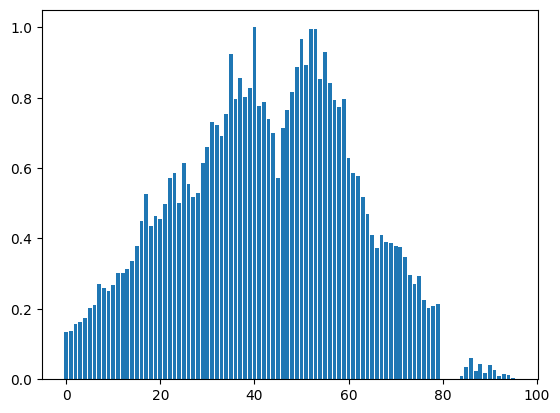

In [67]:
plt.bar(range(96), full_dataset[499])

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [69]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

# Models and testing

In [70]:
pt = torch.zeros(20).reshape(1,1,20)
generator = nn.Sequential(
                nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3))
torch.flatten(generator(pt)).shape

torch.Size([2320])

In [71]:
LATENT_DIM = 22

In [72]:
type(dataset[4])

numpy.ndarray

In [73]:
pt = full_dataset[22].reshape(1,1,96)
enc = nn.Sequential(
       nn.Conv1d(in_channels=1, out_channels=2, kernel_size=8, padding=1),
       nn.Conv1d(in_channels=2, out_channels=4, kernel_size=6, padding=1),
       nn.Conv1d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
       nn.Conv1d(in_channels=8, out_channels=4, kernel_size=3, padding=1),
       nn.Conv1d(in_channels=4, out_channels=2, kernel_size=3, stride=2, padding=1),
       nn.Conv1d(in_channels=2, out_channels=1, kernel_size=3, stride=2, padding=1), # output 1, 1, 22
)
enc(pt).shape

torch.Size([1, 1, 22])

In [74]:
pt = torch.tensor(full_dataset[:32]).reshape(32, 1, 96)
conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=8, padding=1)
conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=6, padding=1)
conv3 = nn.Conv1d(in_channels=8, out_channels=12, kernel_size=3, stride=2, padding=1)
conv4 = nn.Conv1d(in_channels=12, out_channels=16, kernel_size=3, stride=2, padding=1)
fc1 = nn.Linear(in_features=352, out_features=128)
fc2 = nn.Linear(in_features=128, out_features=1)
fc2(fc1(torch.flatten(conv4(conv3(conv2(conv1(pt)))), start_dim=1, end_dim=-1))).shape

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_41152\991333952.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pt = torch.tensor(full_dataset[:32]).reshape(32, 1, 96)


torch.Size([32, 1])

In [75]:
class Generator(nn.Module):
    """Generates new data from the latent space"""
    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(in_features=30, out_features=44) 
        self.fc2 = nn.Linear(in_features=44, out_features=64)
        self.fc3 = nn.Linear(in_features=64, out_features=80)
        self.fc4 = nn.Linear(in_features=80, out_features=96)

    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.sigmoid(self.fc4(x))
        return x

class Discriminator(nn.Module):
    """Takes real data and input from Generator predicts real/fake class"""
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=8, padding=1)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=6, padding=1)
        self.conv3 = nn.Conv1d(in_channels=8, out_channels=12, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv1d(in_channels=12, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(in_features=352, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=1)

    def forward(self, x, return_features=False):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        features = torch.flatten(self.conv4(x), start_dim=1, end_dim=-1)
        x = torch.flatten(F.relu(features), start_dim=1, end_dim=-1)
        x = F.relu(self.fc1(x))
        out = self.fc2(x)
        
        if return_features:
            return out, features
        else:
            return out

class Encoder(nn.Module):
    """Maps real data into latent space"""
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(in_features=96, out_features=80) 
        self.fc2 = nn.Linear(in_features=80, out_features=64)
        self.fc3 = nn.Linear(in_features=64, out_features=44)
        self.fc4 = nn.Linear(in_features=44, out_features=30)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.sigmoid(self.fc4(x))
        return x

In [76]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset

## Training params

In [77]:
batch_size = 32

torch_df = HistDataset(full_dataset)
dataloader = DataLoader(torch_df, batch_size=batch_size, shuffle=True)

gen = Generator()
critic = Discriminator()
encoder = Encoder()

latent_dim = 30
lr = 5e-5
batch_size = 32
num_epochs_gan = 160    # previously 160
num_epochs_enc = 160    # previously 160
critic_iterations = 4 # previously 8
lambda_gp = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_E = torch.optim.Adam(encoder.parameters(), lr=lr)

In [78]:
def gradient_penalty(critic, real, fake):
    batch_size = real.size(0)

    eps = torch.rand(batch_size, 1, 1, device=real.device)

    # (B,1,1) to (B,1,96)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = critic(x_hat)

    gradients = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp


## Training

In [79]:
for real_data in dataloader:
        real_data = real_data.to(device)
        batch_size_gan_training = real_data.shape[0]
        break

z = torch.randn(batch_size_gan_training, 1, latent_dim, device=device)
fake_data = gen(z).detach()

fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
real_data = real_data.reshape(batch_size_gan_training, 1, 96)


loss_C = (
    critic(fake_data).mean() - critic(real_data).mean()
)
z_pt = torch.randn(1, 1, latent_dim)
fake_pt = gen(z_pt).detach().reshape(1,1,96)
print(fake_pt.shape)
#print('Fake data', fake_data.shape)
print(f"Critic outputs: {critic(fake_pt).shape}")
#print(f"Critic fake data mean: {critic(fake_data).mean()}")

torch.Size([1, 1, 96])
Critic outputs: torch.Size([1, 1])


In [80]:
gen.train()
critic.train()

for epoch in range(num_epochs_gan):
    for real_data in dataloader:
        real_data = real_data.to(device)
        batch_size_gan_training = real_data.shape[0]
        
        # critic loop
        for _ in range(critic_iterations):
            z = torch.randn(batch_size_gan_training, 1, latent_dim, device=device)
            fake_data = gen(z).detach()

            fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
            real_data = real_data.reshape(batch_size_gan_training, 1, 96)

            loss_C = (
                critic(fake_data).mean() - critic(real_data).mean()
            )

            gp = gradient_penalty(critic, real_data, fake_data)
            loss_C_total = loss_C + lambda_gp * gp

            optimizer_C.zero_grad()
            loss_C_total.backward()
            optimizer_C.step()

        # generator part
        z = torch.randn(batch_size_gan_training, 1, latent_dim, device=device)
        fake_data = gen(z)
        fake_data = fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
        
        # TODO: preco je tu minus (ocividne chceme nieco maximalizovat ale co je ta idea)
        loss_G = -critic(fake_data).mean()

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{num_epochs_gan} | "
              f"D: {loss_C.item():.4f} | G: {loss_G.item():.4f}")


Epoch 0/160 | D: -0.0047 | G: -0.0596
Epoch 20/160 | D: -2.3396 | G: 0.4850
Epoch 40/160 | D: -0.5733 | G: -0.3060
Epoch 60/160 | D: -0.5163 | G: 0.6481
Epoch 80/160 | D: -0.2950 | G: 0.1305
Epoch 100/160 | D: -0.6410 | G: 2.6446
Epoch 120/160 | D: -1.1477 | G: 2.0599
Epoch 140/160 | D: -0.3006 | G: 4.9279


In [81]:
for p in gen.parameters():
    p.requires_grad = False

for p in critic.parameters():
    p.requires_grad = False

In [82]:
batch_size = 32

In [83]:
alpha = 0.9
beta = 0.1

encoder.train()

for epoch in range(num_epochs_enc):
    for x in dataloader:
        batch_size_encoder_training = x.shape[0]
        
        x = x.to(device)
        x = x.reshape(batch_size_encoder_training, 1, 96)

        z = encoder(x)
        x_hat = gen(z)

        # reconstruction loss
        loss_rec = torch.mean(torch.abs(x - x_hat))

        # feature matching
        _, feat_x = critic(x, return_features=True)
        x_hat = x_hat.reshape(batch_size_encoder_training, 1, 96)
        _, feat_x_hat = critic(x_hat, return_features=True)

        loss_feat = torch.mean(torch.abs(feat_x - feat_x_hat))

        loss_E = alpha * loss_rec + beta * loss_feat

        optimizer_E.zero_grad()
        loss_E.backward()
        optimizer_E.step()

    if epoch % 10 == 0:
        print(f"[ENC] Epoch {epoch}/{num_epochs_enc} | "
              f"Rec: {loss_rec.item():.4f} | Feat: {loss_feat.item():.4f}")


[ENC] Epoch 0/160 | Rec: 0.1205 | Feat: 0.0920
[ENC] Epoch 10/160 | Rec: 0.0935 | Feat: 0.0713
[ENC] Epoch 20/160 | Rec: 0.0804 | Feat: 0.0577
[ENC] Epoch 30/160 | Rec: 0.0709 | Feat: 0.0515
[ENC] Epoch 40/160 | Rec: 0.0830 | Feat: 0.0566
[ENC] Epoch 50/160 | Rec: 0.0798 | Feat: 0.0606
[ENC] Epoch 60/160 | Rec: 0.0797 | Feat: 0.0527
[ENC] Epoch 70/160 | Rec: 0.0811 | Feat: 0.0519
[ENC] Epoch 80/160 | Rec: 0.0760 | Feat: 0.0524
[ENC] Epoch 90/160 | Rec: 0.0678 | Feat: 0.0432
[ENC] Epoch 100/160 | Rec: 0.0638 | Feat: 0.0410
[ENC] Epoch 110/160 | Rec: 0.0809 | Feat: 0.0491
[ENC] Epoch 120/160 | Rec: 0.0715 | Feat: 0.0453
[ENC] Epoch 130/160 | Rec: 0.0592 | Feat: 0.0325
[ENC] Epoch 140/160 | Rec: 0.0579 | Feat: 0.0297
[ENC] Epoch 150/160 | Rec: 0.0662 | Feat: 0.0435


In [84]:
def anomaly_score(x):
    with torch.no_grad():
        encoder.eval()
        z = encoder(x)
        x_hat = gen(z)
        
        rec = torch.mean(torch.abs(x - x_hat), dim=(1,2))
        x_hat = x_hat.reshape(1, 1, 96)
        _, fx = critic(x, return_features=True)
        _, fx_hat = critic(x_hat, return_features=True)

        feat = torch.mean(torch.abs(fx - fx_hat), dim=1)
        return alpha * rec + beta * feat


In [85]:
anomaly_score(full_dataset[3].reshape(1,1,96))

tensor([0.0626])

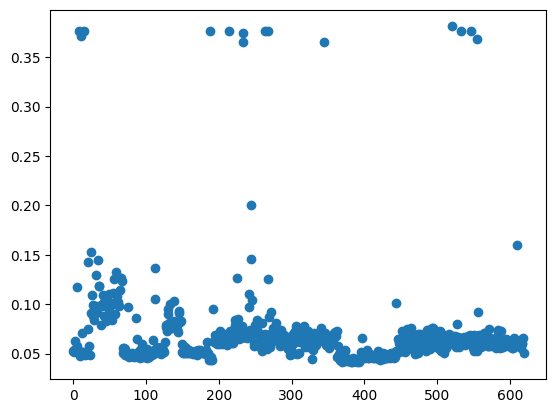

In [86]:
scores = []
for data in full_dataset:
    scores.append(anomaly_score(data.reshape(1, 1, 96)))
plt.scatter(range(len(scores)), scores)

In [87]:
[idx for idx, sc in enumerate(scores) if sc > 0.44]

[]

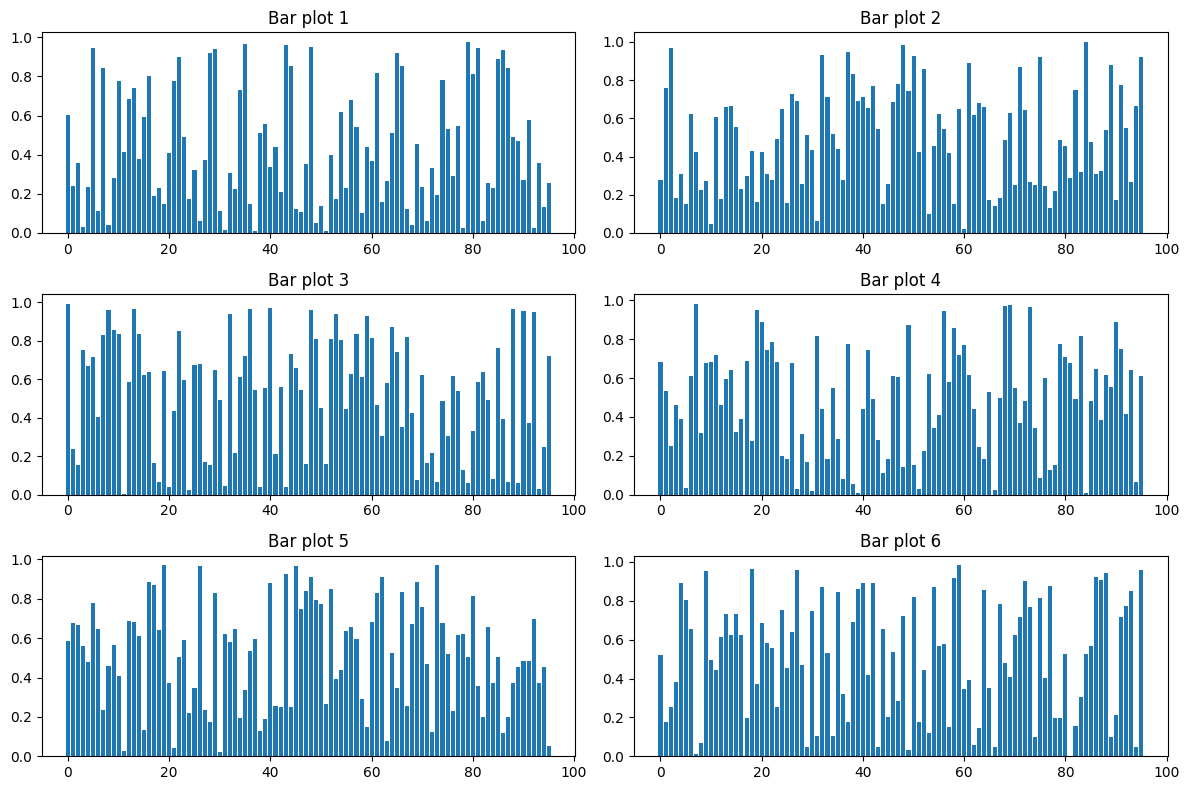

In [88]:
randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

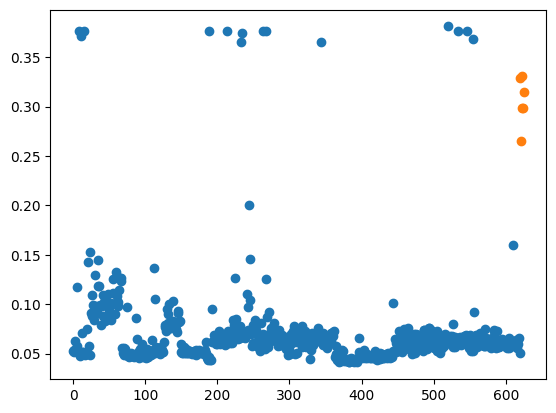

In [89]:
out_scores = []
for out in randoms:
    score = anomaly_score(out.reshape(1,1,96))
    out_scores.append(score)
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(scores), len(scores) + len(out_scores)), out_scores)
plt.show()

# Evaluation and results

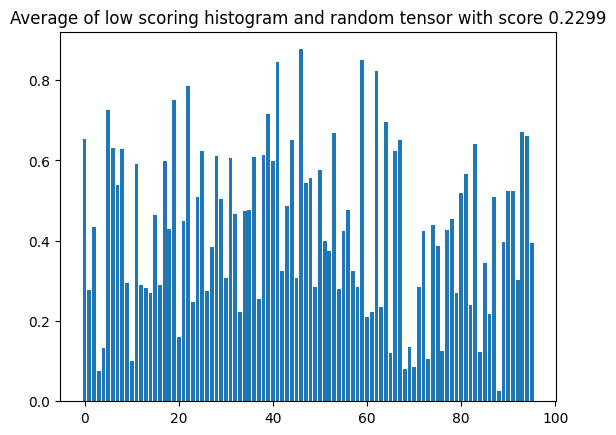

In [90]:
new_pt = (1.4*torch.rand(96) + 0.6*full_dataset[90])/2
plt.bar(range(len(new_pt)), new_pt)
score = anomaly_score(new_pt.reshape(1,1,96))
plt.title(f"Average of low scoring histogram and random tensor with score {score.item():.4f}")
plt.show()

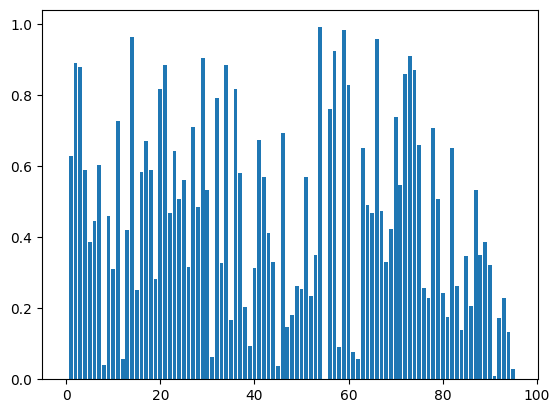

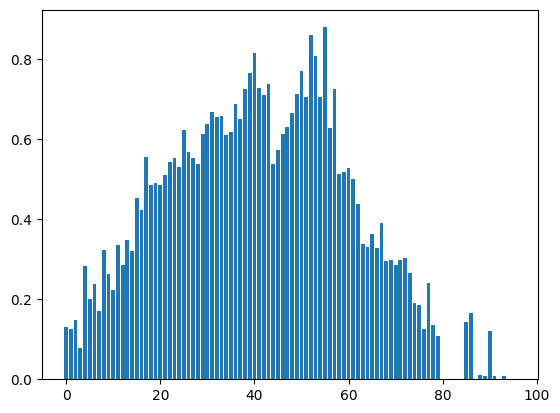

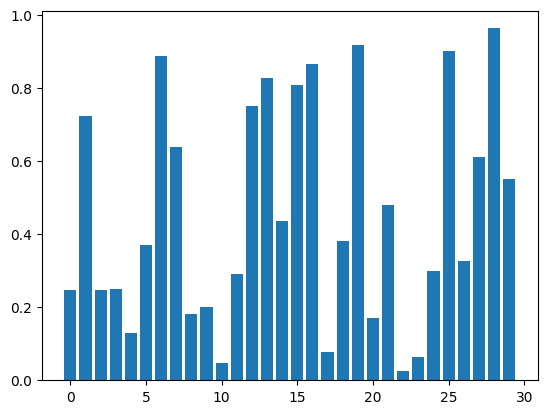

In [91]:
gen.eval()
encoder.eval()

orig_hist = torch.rand(96)
embed = encoder(orig_hist.reshape(1,1,96)).detach()
reconstruct = gen(embed.reshape(1,1,30)).detach().numpy().squeeze()

plt.bar(range(len(orig_hist)), orig_hist)
plt.show()

plt.bar(range(len(reconstruct)), reconstruct)
plt.show()

plt.bar(range(len(embed.numpy().squeeze())), embed.numpy().squeeze())
plt.show()

In [92]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.config.paths import CHECKPOINT_DIR
import time

torch.save({
    "generator": gen.state_dict(),
    "discriminator": critic.state_dict(),
    "encoder": encoder.state_dict(),
    "config": {
        "input_dim": 96,
        "latent_dim": 30,
    }
}, f"{CHECKPOINT_DIR}/f_anogan_simplest_train_date={time.strftime("%d-%m_%H-%M")}.pth")